# 📘 Análisis de Inventario

Este notebook calcula la rotación de inventario: días entre llegada y venta, días promedio, y análisis por equipo y talla.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "data_jerseys_cleaned.csv"

# Leer datos
df = pd.read_csv(
    csv_path,
    parse_dates=['Fecha de compra','Fecha llegada','Fecha de venta'],
    encoding='latin-1'
)

# (Opcional) Revisar duplicados antes de eliminarlos
# print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates()

# Excluir no vendidos y sin fecha de llegada
df_inv = df.dropna(subset=['Fecha de venta','Fecha llegada']).copy()

# Calcular días entre llegada y venta
df_inv['dias_venta'] = (df_inv['Fecha de venta'] - df_inv['Fecha llegada']).dt.days

# Corregir casos negativos (ventas bajo pedido o error de captura)
df_inv.loc[df_inv['dias_venta'] < 0, 'dias_venta'] = 0

# -------------------
# MÉTRICAS GENERALES
# -------------------

dias_promedio = df_inv['dias_venta'].mean()
dias_mediana = df_inv['dias_venta'].median()

# -------------------
# ANÁLISIS POR GRUPO
# -------------------

dias_por_equipo = df_inv.groupby('equipo')['dias_venta'].mean().sort_values()
dias_por_talla = df_inv.groupby('Talla')['dias_venta'].mean().sort_values()

# -------------------
# CASOS EXTREMOS
# -------------------

pedido_rapido = df_inv.loc[df_inv['dias_venta'].idxmin()]
pedido_lento = df_inv.loc[df_inv['dias_venta'].idxmax()]

# -------------------
# TOP MÁS RÁPIDOS
# -------------------

top_rapidos = df_inv.sort_values('dias_venta').head(10)

# Mostrar resultados principales
dias_promedio, dias_mediana, pedido_rapido, pedido_lento

(np.float64(22.666666666666668),
 np.float64(10.0),
 Pedido                                1
 Fecha de compra     2025-06-12 00:00:00
 Fecha llegada       2025-07-03 00:00:00
 Tiempo en llegar                     21
 Fecha de venta      2025-07-03 00:00:00
 equipo                     FC Barcelona
 deporte                          Futbol
 version                           Local
 temporada                     2025/2026
 Jugador                    LAMINE YAMAL
 Talla                                 L
 Proveedor                       Alibaba
 Costo                              11.0
 Costo de envio                      6.0
 Costo total                        17.0
 Venta                             48.19
 Ganancia                          31.19
 dias_venta                            0
 Name: 1, dtype: object,
 Pedido                                3
 Fecha de compra     2025-07-11 00:00:00
 Fecha llegada       2025-08-12 00:00:00
 Tiempo en llegar                     32
 Fecha de venta      

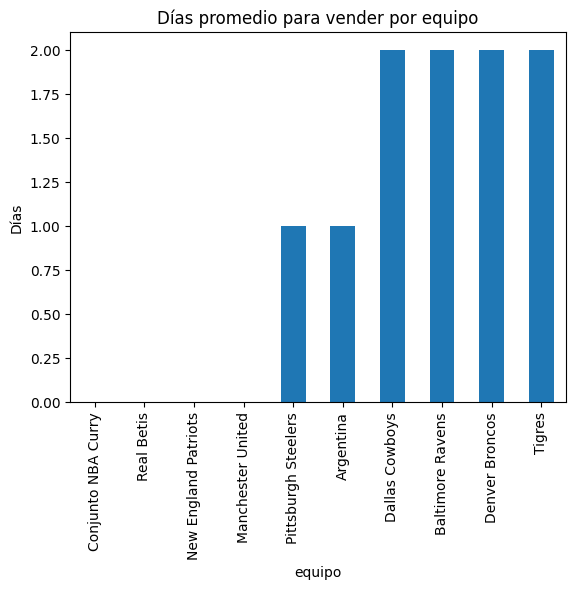

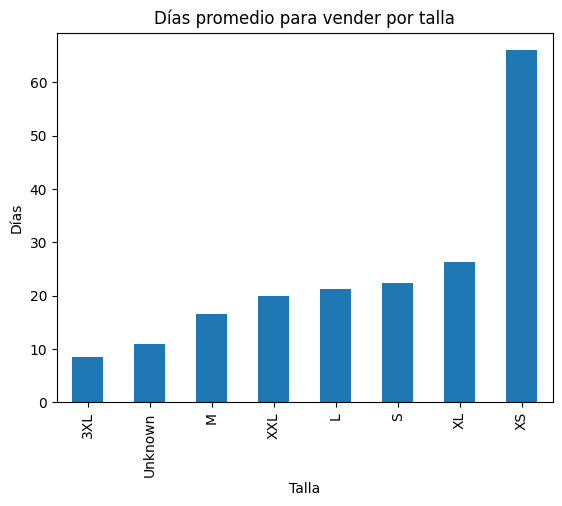

Días promedio en vender: 22.666666666666668
Pedido más rápido en vender (fila):
Pedido                                1
Fecha de compra     2025-06-12 00:00:00
Fecha llegada       2025-07-03 00:00:00
Tiempo en llegar                     21
Fecha de venta      2025-07-03 00:00:00
equipo                     FC Barcelona
deporte                          Futbol
version                           Local
temporada                     2025/2026
Jugador                    LAMINE YAMAL
Talla                                 L
Proveedor                       Alibaba
Costo                              11.0
Costo de envio                      6.0
Costo total                        17.0
Venta                             48.19
Ganancia                          31.19
dias_venta                            0
Name: 1, dtype: object
Pedido más lento en vender (fila):
Pedido                                3
Fecha de compra     2025-07-11 00:00:00
Fecha llegada       2025-08-12 00:00:00
Tiempo en llegar      

In [16]:
# visualizaciones
dias_por_equipo.head(10).plot(kind='bar', title='Días promedio para vender por equipo')
plt.ylabel('Días')
plt.show()

dias_por_talla.head(10).plot(kind='bar', title='Días promedio para vender por talla')
plt.ylabel('Días')
plt.show()

print('Días promedio en vender:', dias_promedio)
print('Pedido más rápido en vender (fila):')
print(pedido_rapido)
print('Pedido más lento en vender (fila):')
print(pedido_lento)